# GPQR Tutoral

Gaussian process quantile regression (GPQR) estimates quantile function using Gaussian process regression with asymmetric laplace distribution (ALD) likelihood.

In this tutorial, we estimate multiple quantile levels using multitask learning for the following data with heteroscedastic noise:

$$Y = \cos(2\pi X) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, X + 0.1).$$

To avoid quantile crossing, center-gap representation is used.
Informative prior is applied by setting prior mean function to the central quantile.

Correlation between gaps are modeled by using linear model of coregionalization (LMC) of latent functions.
To facilitate implementation, a special structure of center-gap LMC is used where central quantile is independent to gaps.
This allows prior mean of latent functions to be directly set.

In [ ]:
import os
import torch
import gpytorch
import matplotlib.pyplot as plt

from gpytorch_qr.means import CenterGapMean
from gpytorch_qr.models import CenterGapQuantileGP
from gpytorch_qr.variational import CenterGapLMCVariationalStrategy
from gpytorch_qr.likelihoods import CenterGapQuantileLikelihood

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 5000))

We generate sinusiodal data with heteroscedastic noise.

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x_range = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
x = x_range.repeat(5, 1)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9]).to(device)
true_quantiles = mean(x_range) + std(x_range) * torch.distributions.Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

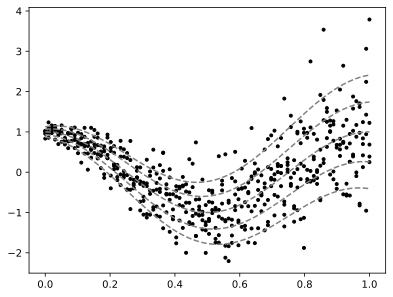

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

## Placing prior mean

We place prior mean for the median quantile.
Other quantiles will have prior means with constant offset to the median.

In [ ]:
class PriorMean(gpytorch.means.Mean):
    def __init__(self, batch_shape=torch.Size()):
        super().__init__()
        self.batch_shape = batch_shape

    def forward(self, x):
        return mean(x).squeeze(-1).expand(*self.batch_shape, x.shape[-2])

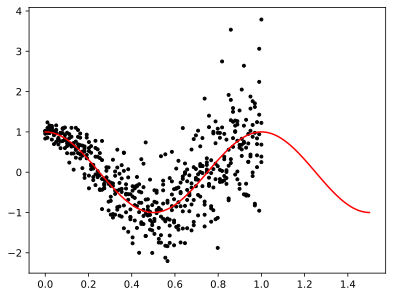

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_pred.cpu(), PriorMean()(x_pred).detach().cpu(), c="r")
plt.show()

## Define model and likelihood

To model the correlation between quantiles, the number of latent GP should be smaller than the number of tasks (= number of quantiles).

In [ ]:
class MyGP(CenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
    ):
        N, D = inducing_points.size()
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = CenterGapLMCVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles,
            num_latents,
            num_quantiles=[num_quantiles],
            num_lower_quantiles=[num_lower_quantiles],
        )

        mean = CenterGapMean(
            PriorMean(batch_shape=torch.Size([1])),
            gpytorch.means.ConstantMean(batch_shape=torch.Size([num_latents - 1])),
        )
        covar = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                ard_num_dims=D, batch_shape=torch.Size([num_latents])
            ),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(
            variational_strategy, mean, covar, [num_quantiles], [num_lower_quantiles]
        )


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
central_q_index = 2
num_latents = 3
gp = MyGP(inducing_points, len(q), central_q_index, num_latents).to(device)
likelihood = CenterGapQuantileLikelihood(q, central_q_index).to(device)

## Training the model

In [ ]:
gp.train()
likelihood.train()
mll = gpytorch.mlls.VariationalELBO(likelihood, gp, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

## Estimating the result

Because center-gap architecture leads to non-analytic posterior of quantiles, we estimate the mean and credible interval of quantiles using Monte-Carlo sampling.

In [ ]:
gp.eval()
with torch.no_grad():
    mean_q = gp.mean_quantiles_mc(x_pred)
    lower_q, upper_q = gp.quantile_quantiles_mc(
        x_pred, torch.tensor([0.025, 0.975]).to(device)
    )

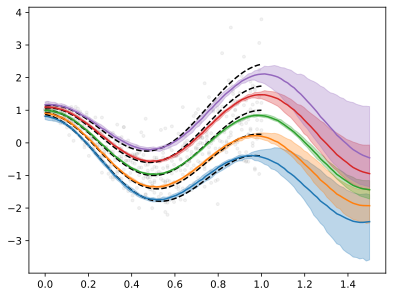

In [ ]:
colors = plt.cm.tab10.colors

plt.scatter(x.cpu(), y.cpu(), c="gray", marker=".", alpha=0.1)
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="k")

for i in range(len(q)):
    plt.plot(x_pred.cpu(), mean_q[:, i].cpu(), color=colors[i])
    plt.fill_between(
        x_pred.cpu().squeeze(),
        lower_q[:, i].cpu(),
        upper_q[:, i].cpu(),
        color=colors[i],
        alpha=0.3,
    )
plt.show()